# 🧠 ASD Detection — Paper-Ready Pipeline
### TabICLv2 vs TabPFN vs XGBoost · LOOCV · Severity Scoring · Explainability

**Design principles (leak-free):**
| Guarantee | How |
|---|---|
| No test leakage in feature selection | FDR runs on participant-means of **training fold only** |
| No test leakage in model | `LeaveOneGroupOut` — left-out participant's trials never in training |
| No threshold circularity | Fixed 0.5 as primary; Youden-J reported as secondary after all folds complete |
| Severity score | Soft-vote P(ASD) mapped to Low / Borderline / High bands |
| Explainability | Per-participant local permutation importance + SHAP (XGBoost) |
| Baseline comparison | TabPFN & XGBoost identical LOOCV; McNemar pairwise significance tests |


In [ ]:
import subprocess, sys



PKGS = {
    'tabicl':      'tabicl[finetune]',
    'tabpfn':      'tabpfn',
    'skrub':       'skrub',
    'sklearn':     'scikit-learn',
    'statsmodels': 'statsmodels',
    'pandas':      'pandas',
    'numpy':       'numpy',
    'matplotlib':  'matplotlib',
    'shap':        'shap',
    'joblib':      'joblib',
    'scipy':       'scipy',
    'tqdm':        'tqdm',
    'xgboost':     'xgboost',
}
for import_name, pip_name in PKGS.items():
    try:
        __import__(import_name)
    except ImportError:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
print('✅ All dependencies ready')


Installing tabicl[finetune]...
Installing tabpfn...
Installing skrub...
✅ All dependencies ready


### Set Hugging Face Token

To avoid warnings and enable higher rate limits when interacting with the Hugging Face Hub, an authentication token can be set. For persistent and secure storage of your token, it's recommended to use Colab's secret manager (the '🔑' icon on the left panel).

For this session, I will set the provided token directly as an environment variable.

In [15]:
import os

# ── Hugging Face token ────────────────────────────────────────────────────────
# Set HF_TOKEN as a Colab secret (🔑 icon) or environment variable before running.
# Never hard-code tokens in shared notebooks.
#
# Option A — Colab secrets (recommended):
#   from google.colab import userdata
#   os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
#
# Option B — environment variable set before kernel start:
#   export HF_TOKEN=<your_token>

if 'HF_TOKEN' not in os.environ:
    print('⚠️  HF_TOKEN not set. Set it via Colab secrets or environment variable.')
else:
    print('✅ HF_TOKEN detected in environment.')


✅ HF_TOKEN environment variable set.


In [16]:
import os, sys, json, time, datetime, warnings, zipfile
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.stats              import shapiro, mannwhitneyu, ttest_ind
from tqdm.notebook            import tqdm
from sklearn.model_selection  import LeaveOneGroupOut
from sklearn.metrics          import (roc_auc_score, f1_score, recall_score,
                                      confusion_matrix, classification_report,
                                      accuracy_score, roc_curve, brier_score_loss)
from sklearn.pipeline         import Pipeline
from statsmodels.stats.multitest        import multipletests
from statsmodels.stats.contingency_tables import mcnemar

import shap
from xgboost   import XGBClassifier
from skrub     import TableVectorizer
from tabicl    import TabICLClassifier
try:
    from tabicl import FinetunedTabICLClassifier
    HAS_FINETUNE = True
except ImportError:
    HAS_FINETUNE = False
    print('⚠️  FinetunedTabICLClassifier not available')

try:
    from tabpfn import TabPFNClassifier
    HAS_TABPFN = True
except ImportError:
    HAS_TABPFN = False
    print('⚠️  TabPFN not available — pip install tabpfn')

import torch
print('✅ Imports ready')
print(f'   PyTorch  : {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
print(f'   Fine-tune: {HAS_FINETUNE}  |  TabPFN: {HAS_TABPFN}')


✅ Imports ready
   PyTorch  : 2.10.0+cu128  |  CUDA: True
   Fine-tune: True  |  TabPFN: True


In [ ]:
import os, zipfile, warnings
import numpy as np
import pandas as pd
from scipy.stats import linregress
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────────────
ZIP_PATH_RAW = 'processed_data_fixed.zip'
try:
    import google.colab; IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists(ZIP_PATH_RAW):
    from google.colab import files
    uploaded = files.upload()
    ZIP_PATH_RAW = list(uploaded.keys())[0]

OUTPUT_CSV = 'trial_features_highend_fixed.csv'

# ── Constants (FIX 5: 500 ms blink threshold, matching highend_fixed script) ──
LONG_BLINK_MS    = 500.   # FIX 5: was 300 in old notebook — highend_fixed uses 500
BLINK_SHORT_MS   = 100    # blinks shorter than this are not interpolated
MIN_TRIAL_DUR_MS = 100.
MIN_FIXATIONS    = 3      # FIX 7: skip trials with < 3 fixations
MIN_TRACK_RATIO  = 50.0   # FIX 6: tracking quality filter

# ── Column name constants ─────────────────────────────────────────────────────
C_TIME        = 'RecordingTime [ms]'
C_CAT_GROUP   = 'Category Group'
C_CAT_RIGHT   = 'Category Right'
C_IDX_RIGHT   = 'Index Right'
C_GAZE_RX     = 'Point of Regard Right X [px]'
C_GAZE_RY     = 'Point of Regard Right Y [px]'
C_GAZE_LX     = 'Point of Regard Left X [px]'
C_GAZE_LY     = 'Point of Regard Left Y [px]'
C_PUPIL_R     = 'Pupil Diameter Right [mm]'
C_PUPIL_L     = 'Pupil Diameter Left [mm]'
C_TRACK_RATIO = 'Tracking Ratio [%]'
C_TRIAL       = 'Trial'
C_STIMULUS    = 'Stimulus'
C_PARTICIPANT = 'Participant'   # FIX: added to match highend_fixed script


# ── FIX 6: Blink interpolation ────────────────────────────────────────────────
def interpolate_blinks(df):
    """NaN-out blink-affected samples and linearly interpolate."""
    if C_CAT_RIGHT not in df.columns or C_TIME not in df.columns:
        return df
    df = df.copy()
    is_blink = df[C_CAT_RIGHT] == 'Blink'
    blocks   = (is_blink != is_blink.shift()).cumsum()
    for _, grp in df[is_blink].groupby(blocks[is_blink]):
        idx   = grp.index
        times = df.loc[idx, C_TIME].dropna().values
        if len(times) < 2:
            continue
        if (times[-1] - times[0]) >= BLINK_SHORT_MS:
            for col in [C_GAZE_RX, C_GAZE_RY, C_GAZE_LX, C_GAZE_LY, C_PUPIL_R, C_PUPIL_L]:
                if col in df.columns:
                    df.loc[idx, col] = np.nan
    for col in [C_GAZE_RX, C_GAZE_RY, C_GAZE_LX, C_GAZE_LY, C_PUPIL_R, C_PUPIL_L]:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear', limit_area='inside')
    return df


# ── FIX 1: Raw-row pupil z-scoring per participant (before trial split) ───────
def zscore_pupil_raw(df):
    """
    Z-score raw pupil columns within the full participant recording.
    Must be called on the full participant DataFrame BEFORE the trial loop.
    """
    df = df.copy()
    for col in [C_PUPIL_R, C_PUPIL_L]:
        if col in df.columns:
            vals = df[col].dropna()
            if len(vals) > 1 and vals.std() > 1e-9:
                df[col] = (df[col] - vals.mean()) / vals.std()
            else:
                df[col] = 0.0
    return df


def safe_stat(arr, fn):
    a = arr[~np.isnan(arr)] if len(arr) > 0 else arr
    return float(fn(a)) if len(a) > 0 else 0.0


# ── FIX 2 + 3 + 4: Feature extraction (one trial) ────────────────────────────
def extract_trial_features(df_trial, trial_dur_ms):
    """
    31 features per trial (matching the highend_fixed script exactly).

    FIX 2: fix_dispersion_mean uses per-fixation std_x + std_y (within-fixation
            spread), NOT cross-fixation std across all fixation positions.
    FIX 3: fix_seq_norm = normalised ordinal index (seq.mean/seq.max).
    FIX 4: sac_fix_ratio = n_sac / (n_fix + n_sac), bounded [0,1].
    """
    dur_min = max(trial_dur_ms / 60_000, 1e-9)

    fix = df_trial[df_trial[C_CAT_RIGHT] == 'Fixation'].copy()
    sac = df_trial[df_trial[C_CAT_RIGHT] == 'Saccade'].copy()
    blk = df_trial[df_trial[C_CAT_RIGHT] == 'Blink'].copy()

    # ── Fixation events ───────────────────────────────────────────────────────
    if len(fix) > 0 and C_IDX_RIGHT in fix.columns and fix[C_IDX_RIGHT].notna().sum() > 0:
        groups = (fix[C_IDX_RIGHT] != fix[C_IDX_RIGHT].shift()).cumsum()
    else:
        groups = (fix[C_CAT_RIGHT] != fix[C_CAT_RIGHT].shift()).cumsum() if len(fix) > 0 else None

    fix_events = []
    if len(fix) > 0 and groups is not None:
        for seq, grp in fix.groupby(groups):
            times = grp[C_TIME].dropna().values if C_TIME in grp.columns else np.array([])
            if len(times) == 0:
                continue
            dur = float(times[-1] - times[0]) if len(times) > 1 else 0.0
            x   = grp[C_GAZE_RX].dropna().values if C_GAZE_RX in grp.columns else np.array([])
            y   = grp[C_GAZE_RY].dropna().values if C_GAZE_RY in grp.columns else np.array([])
            pr  = grp[C_PUPIL_R].dropna().values  if C_PUPIL_R in grp.columns else np.array([])
            pl  = grp[C_PUPIL_L].dropna().values  if C_PUPIL_L in grp.columns else np.array([])
            fix_events.append({
                'fix_seq':      int(seq),
                'duration_ms':  dur,
                'start_time':   float(times[0]),
                'mean_x':       float(np.mean(x))  if len(x) > 0 else np.nan,
                'mean_y':       float(np.mean(y))  if len(y) > 0 else np.nan,
                # FIX 2: per-fixation spatial spread (std_x, std_y)
                'std_x':        float(np.std(x))   if len(x) > 1 else 0.0,
                'std_y':        float(np.std(y))   if len(y) > 1 else 0.0,
                'mean_pupil_r': float(np.mean(pr)) if len(pr) > 0 else np.nan,
                'mean_pupil_l': float(np.mean(pl)) if len(pl) > 0 else np.nan,
            })
    fix_ev = (pd.DataFrame(fix_events).sort_values('start_time').reset_index(drop=True)
              if fix_events else pd.DataFrame())
    n_fix = len(fix_ev)
    feats = {}

    if n_fix > 0:
        durs = fix_ev['duration_ms'].values
        feats['fix_count']           = n_fix
        feats['fix_dur_mean_ms']     = safe_stat(durs, np.mean)
        feats['fix_dur_std_ms']      = safe_stat(durs, np.std)
        feats['fix_dur_max_ms']      = safe_stat(durs, np.max)
        feats['fix_dur_cv']          = feats['fix_dur_std_ms'] / (feats['fix_dur_mean_ms'] + 1e-8)
        feats['fix_rate_per_min']    = n_fix / dur_min
        # FIX 2: within-fixation spread, averaged across fixations
        disp = (fix_ev['std_x'].fillna(0) + fix_ev['std_y'].fillna(0)).values
        feats['fix_dispersion_mean'] = safe_stat(disp, np.mean)
        # FIX 3: normalised ordinal index (identical to highend_fixed script)
        feats['fix_seq_norm'] = (fix_ev['fix_seq'].mean() /
                                  (fix_ev['fix_seq'].max() + 1e-8))
        if n_fix >= 2:
            x   = fix_ev['mean_x'].values
            y   = fix_ev['mean_y'].values
            ifd = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
            feats['ifd_mean'] = float(np.nanmean(ifd))
            feats['ifd_std']  = float(np.nanstd(ifd))
        else:
            feats['ifd_mean'] = feats['ifd_std'] = 0.0
    else:
        for k in ['fix_count','fix_dur_mean_ms','fix_dur_std_ms','fix_dur_max_ms',
                  'fix_dur_cv','fix_rate_per_min','fix_dispersion_mean','fix_seq_norm',
                  'ifd_mean','ifd_std']:
            feats[k] = 0.0

    # ── Saccade events ────────────────────────────────────────────────────────
    sac_groups = (sac[C_CAT_RIGHT] != sac[C_CAT_RIGHT].shift()).cumsum() if len(sac) > 0 else None
    sac_events = []
    if len(sac) > 0 and sac_groups is not None:
        for _, grp in sac.groupby(sac_groups):
            x = grp[C_GAZE_RX].dropna().values if C_GAZE_RX in grp.columns else np.array([])
            y = grp[C_GAZE_RY].dropna().values if C_GAZE_RY in grp.columns else np.array([])
            amp = float(np.sqrt((x[-1]-x[0])**2 + (y[-1]-y[0])**2)) if len(x)>1 and len(y)>1 else 0.0
            sac_events.append({'amplitude_px': amp})
    sac_ev = pd.DataFrame(sac_events) if sac_events else pd.DataFrame()
    n_sac  = len(sac_ev)

    if n_sac > 0:
        amps = sac_ev['amplitude_px'].values
        feats['sac_count']          = n_sac
        feats['sac_amplitude_mean'] = safe_stat(amps, np.mean)
        feats['sac_amplitude_std']  = safe_stat(amps, np.std)
        feats['sac_rate_per_min']   = n_sac / dur_min
        # FIX 4: bounded ratio — fraction of oculomotor events that are saccades
        feats['sac_fix_ratio']      = n_sac / (n_fix + n_sac + 1e-8)
    else:
        for k in ['sac_count','sac_amplitude_mean','sac_amplitude_std',
                  'sac_rate_per_min','sac_fix_ratio']:
            feats[k] = 0.0

    # ── Blink events (FIX 5: threshold 500 ms) ────────────────────────────────
    blk_groups = (blk[C_CAT_RIGHT] != blk[C_CAT_RIGHT].shift()).cumsum() if len(blk) > 0 else None
    blk_events = []
    if len(blk) > 0 and blk_groups is not None:
        for _, grp in blk.groupby(blk_groups):
            times = grp[C_TIME].dropna().values if C_TIME in grp.columns else np.array([])
            if len(times) == 0:
                continue
            dur = float(times[-1] - times[0]) if len(times) > 1 else 0.0
            blk_events.append({'duration_ms': dur, 'is_long': int(dur >= LONG_BLINK_MS)})
    blk_ev = pd.DataFrame(blk_events) if blk_events else pd.DataFrame()
    n_blk  = len(blk_ev)

    if n_blk > 0:
        durs = blk_ev['duration_ms'].values
        feats['blink_count']        = n_blk
        feats['blink_dur_mean_ms']  = safe_stat(durs, np.mean)
        feats['blink_rate_per_min'] = n_blk / dur_min
        feats['blink_long_ratio']   = blk_ev['is_long'].sum() / (n_blk + 1e-8)
    else:
        for k in ['blink_count','blink_dur_mean_ms','blink_rate_per_min','blink_long_ratio']:
            feats[k] = 0.0

    # ── Pupil (FIX 1: values already z-scored at participant level before trial loop) ─
    for col, suf in [(C_PUPIL_R, 'r'), (C_PUPIL_L, 'l')]:
        if col in df_trial.columns:
            vals = df_trial[col].dropna().values
            feats[f'pupil_{suf}_mean'] = safe_stat(vals, np.mean)
            feats[f'pupil_{suf}_std']  = safe_stat(vals, np.std)
        else:
            feats[f'pupil_{suf}_mean'] = feats[f'pupil_{suf}_std'] = 0.0

    if C_PUPIL_R in df_trial.columns and C_PUPIL_L in df_trial.columns:
        pr = df_trial[C_PUPIL_R].dropna()
        pl = df_trial[C_PUPIL_L].dropna()
        common = pr.index.intersection(pl.index)
        diff   = (pr.loc[common] - pl.loc[common]).abs() if len(common) > 0 else pd.Series([0.])
        feats['pupil_asymmetry_mean'] = float(diff.mean())
        feats['pupil_asymmetry_std']  = float(diff.std()) if len(diff) > 1 else 0.0
    else:
        feats['pupil_asymmetry_mean'] = feats['pupil_asymmetry_std'] = 0.0

    if C_PUPIL_R in df_trial.columns:
        pvals = df_trial[C_PUPIL_R].dropna().values
        feats['pupil_slope'] = (float(linregress(range(len(pvals)), pvals).slope)
                                if len(pvals) > 2 else 0.0)
    else:
        feats['pupil_slope'] = 0.0

    # ── Gaze position ─────────────────────────────────────────────────────────
    for col, key in [(C_GAZE_RX, 'gaze_x_mean'), (C_GAZE_RY, 'gaze_y_mean')]:
        if col in df_trial.columns:
            vals = df_trial[col].dropna().values
            feats[key] = safe_stat(vals, np.mean)
        else:
            feats[key] = 0.0

    return feats


# ── Main extraction loop ──────────────────────────────────────────────────────
print(f'Extracting features from {ZIP_PATH_RAW} (all 7 fixes applied)')
all_rows = []

with zipfile.ZipFile(ZIP_PATH_RAW, 'r') as zf:
    csv_files = [n for n in zf.namelist()
                 if n.endswith('.csv') and ('/asd/' in n or '/td/' in n)]

    for fname in tqdm(sorted(csv_files), desc='Participants', unit='file'):
        label = 1 if '/asd/' in fname else 0

        with zf.open(fname) as f:
            df_raw = pd.read_csv(f, low_memory=False)

        # ── FIX: Participant ID from data column (matches highend_fixed script) ──
        pid = (str(df_raw[C_PARTICIPANT].dropna().iloc[0])
               if C_PARTICIPANT in df_raw.columns and df_raw[C_PARTICIPANT].notna().any()
               else os.path.splitext(os.path.basename(fname))[0])

        # Clean: replace '-' placeholders, coerce numeric columns
        cat_cols = [C_CAT_GROUP, C_CAT_RIGHT, 'Category Left']
        df_raw[[c for c in df_raw.columns if c not in cat_cols]] =             df_raw[[c for c in df_raw.columns if c not in cat_cols]].replace('-', np.nan)
        for col in [C_TIME, C_IDX_RIGHT, C_GAZE_RX, C_GAZE_RY,
                    C_GAZE_LX, C_GAZE_LY, C_PUPIL_R, C_PUPIL_L, C_TRACK_RATIO]:
            if col in df_raw.columns:
                df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')
        # Zero → NaN for gaze/pupil (invalid tracker output)
        for col in [C_PUPIL_R, C_PUPIL_L, C_GAZE_RX, C_GAZE_RY, C_GAZE_LX, C_GAZE_LY]:
            if col in df_raw.columns:
                df_raw[col] = df_raw[col].replace(0.0, np.nan)

        # Keep Eye rows only
        if C_CAT_GROUP in df_raw.columns:
            df_raw = df_raw[df_raw[C_CAT_GROUP] == 'Eye'].copy()
        if C_CAT_RIGHT in df_raw.columns:
            df_raw = df_raw[~df_raw[C_CAT_RIGHT].isin(['-', 'Separator'])].copy()
            df_raw = df_raw[df_raw[C_CAT_RIGHT].notna()].copy()

        # FIX 6: Drop low-quality tracking rows BEFORE blink interpolation
        if C_TRACK_RATIO in df_raw.columns:
            df_raw = df_raw[df_raw[C_TRACK_RATIO] >= MIN_TRACK_RATIO].copy()

        if len(df_raw) < 50 or C_TRIAL not in df_raw.columns:
            continue

        df_raw = df_raw.sort_values(C_TIME).reset_index(drop=True)

        # FIX 6: Interpolate blinks on full recording before trial split
        df_raw = interpolate_blinks(df_raw)

        # FIX 1: Z-score pupil on full participant recording before trial split
        df_raw = zscore_pupil_raw(df_raw)

        stim_map = (df_raw.groupby(C_TRIAL)[C_STIMULUS].first().to_dict()
                    if C_STIMULUS in df_raw.columns else {})

        for trial_id, grp in df_raw.groupby(C_TRIAL):
            t   = pd.to_numeric(grp[C_TIME], errors='coerce')
            dur = float(t.max() - t.min())
            if dur < MIN_TRIAL_DUR_MS:
                continue

            feats = extract_trial_features(grp.copy(), dur)
            # FIX 7: Skip trials with < 3 fixation events
            if feats['fix_count'] < MIN_FIXATIONS:
                continue

            stim = stim_map.get(trial_id, '')
            feats.update({
                'participant_id': pid,
                'trial':          trial_id,
                'stimulus_type':  1 if str(stim).lower().endswith('.avi') else 0,
                'label':          label,
            })
            all_rows.append(feats)

feat_df = pd.DataFrame(all_rows)

# ── Column order matching highend_fixed script schema ─────────────────────────
COL_ORDER = [
    'participant_id', 'trial', 'stimulus_type',
    'fix_count', 'fix_dur_mean_ms', 'fix_dur_std_ms', 'fix_dur_max_ms',
    'fix_dur_cv', 'fix_rate_per_min', 'fix_dispersion_mean', 'fix_seq_norm',
    'ifd_mean', 'ifd_std',
    'sac_count', 'sac_amplitude_mean', 'sac_amplitude_std',
    'sac_rate_per_min', 'sac_fix_ratio',
    'blink_count', 'blink_dur_mean_ms', 'blink_rate_per_min', 'blink_long_ratio',
    'pupil_r_mean', 'pupil_r_std', 'pupil_l_mean', 'pupil_l_std',
    'pupil_asymmetry_mean', 'pupil_asymmetry_std', 'pupil_slope',
    'gaze_x_mean', 'gaze_y_mean',
    'label',
]
feat_df = feat_df[[c for c in COL_ORDER if c in feat_df.columns]]

# ── Summary ───────────────────────────────────────────────────────────────────
n_parts = feat_df['participant_id'].nunique()
asd_n   = feat_df[feat_df['label']==1]['participant_id'].nunique()
td_n    = feat_df[feat_df['label']==0]['participant_id'].nunique()
n_feats = len(feat_df.columns) - 4
nan_pct = feat_df.iloc[:, 3:-1].isna().mean().mean() * 100

print(f'\n✅ Feature extraction complete (all 7 fixes applied)')
print(f'   Participants : {n_parts}  (ASD={asd_n}, TD={td_n})')
print(f'   Trials       : {len(feat_df)}')
print(f'   Features     : {n_feats}')
print(f'   NaN rate     : {nan_pct:.1f}%')
print('\n   Pupil stats after z-scoring (should be approx mean≈0, std≈1):')
for col in ['pupil_r_mean', 'pupil_r_std', 'pupil_l_mean', 'pupil_l_std']:
    if col in feat_df.columns:
        m = feat_df[col].mean(); s = feat_df[col].std()
        print(f'     {col:<18}  mean={m:+.3f}  std={s:.3f}')

feat_df.to_csv(OUTPUT_CSV, index=False)
print(f'\n   Saved → {OUTPUT_CSV}')
FEATURE_FILE = OUTPUT_CSV


In [ ]:
ZIP_PATH     = 'processed_data_fixed.zip'
FEATURE_FILE = 'trial_features_highend_fixed.csv'  # written by Feature Extraction cell above

try:
    import google.colab; IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os
if IN_COLAB and not os.path.exists(FEATURE_FILE):
    if not os.path.exists(ZIP_PATH):
        from google.colab import files
        uploaded = files.upload()
        if uploaded:
            ZIP_PATH = list(uploaded.keys())[0]

# ── Pipeline hyperparameters ──────────────────────────────────────────────────
RANDOM_STATE  = 42
ALPHA         = 0.05
N_ESTIMATORS  = 64
N_PERM        = 1000
N_BOOT        = 2000
HOLDOUT_RATIO = 0.20
META_COLS     = ['participant_id', 'trial', 'stimulus_type', 'label']
OUTPUT_DIR    = 'results_paper'
SPLIT_FILE    = os.path.join(OUTPUT_DIR, 'split_indices.json')
HOLDOUT_FLAG  = os.path.join(OUTPUT_DIR, '.holdout_used')
SEV_LOW   = 0.40
SEV_HIGH  = 0.70
FINETUNE_LR     = 2e-5
FINETUNE_EPOCHS = 10

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Config ready')
print(f'   Feature file : {FEATURE_FILE}')
print(f'   Output dir   : {OUTPUT_DIR}')
if not os.path.isfile(FEATURE_FILE):
    print(f'⚠️  {FEATURE_FILE!r} not found — run the Feature Extraction cell above first')


### Feature plain-language dictionary
Used in all explainability outputs so clinical readers understand what each metric means.


In [57]:
# ── PASTE THIS into your notebook, replacing the old FEATURE_PLAIN block ──────
# The 4 old pupil_mean / pupil_std entries are replaced by the 4 split columns.

FEATURE_PLAIN = {
    'fix_count':            'Number of times eyes stopped to focus',
    'fix_dur_mean_ms':      'Average duration of each eye pause (ms)',
    'fix_dur_std_ms':       'Variability in eye pause duration',
    'fix_dur_max_ms':       'Longest single eye pause (ms)',
    'fix_dur_cv':           'Consistency of eye pauses (coefficient of variation)',
    'fix_rate_per_min':     'How often eyes paused per minute',
    'fix_dispersion_mean':  'How spread out eye pauses were across the screen',
    'fix_seq_norm':         'Orderliness of the eye-pause sequence',
    'ifd_mean':             'Average distance between consecutive eye pauses',
    'ifd_std':              'Variability in distance between eye pauses',
    'sac_count':            'Number of rapid eye jumps (saccades)',
    'sac_amplitude_mean':   'Average size of eye jumps',
    'sac_amplitude_std':    'Variability in eye jump size',
    'sac_rate_per_min':     'How often eyes made rapid jumps per minute',
    'sac_fix_ratio':        'Balance between eye jumps and eye pauses',
    'blink_count':          'Total number of blinks',
    'blink_dur_mean_ms':    'Average blink duration (ms)',
    'blink_rate_per_min':   'How often the participant blinked per minute',
    'blink_long_ratio':     'Proportion of unusually long blinks',
    # FIX: split into separate right / left columns (z-scored per participant)
    'pupil_r_mean':         'Average right pupil size (z-scored within participant)',
    'pupil_r_std':          'Variability in right pupil size (z-scored within participant)',
    'pupil_l_mean':         'Average left pupil size (z-scored within participant)',
    'pupil_l_std':          'Variability in left pupil size (z-scored within participant)',
    'pupil_asymmetry_mean': 'Average difference in size between left and right pupil',
    'pupil_asymmetry_std':  'Variability in pupil size asymmetry',
    'pupil_slope':          'How right pupil size changed over the viewing session',
    'gaze_x_mean':          'Average horizontal gaze position on screen',
    'gaze_y_mean':          'Average vertical gaze position on screen',
}

def plain(feat):
    """Return plain-language label for a feature, falling back to raw name."""
    return FEATURE_PLAIN.get(feat, feat)

print('✅ Feature dictionary ready')
print(f'   {len(FEATURE_PLAIN)} features mapped to plain-language labels')

✅ Feature dictionary ready
   28 features mapped to plain-language labels


In [63]:
def load_data(path=FEATURE_FILE):
    if not os.path.exists(path):
        raise FileNotFoundError(f"'{path}' not found.")
    df = pd.read_csv(path, low_memory=False)
    df = df.dropna(axis=1, how='all')
    # Filter out any leftover peak_vel if they exist
    df = df[[c for c in df.columns if 'peak_vel' not in c]]
    feat_cols = [c for c in df.columns if c not in META_COLS]
    df[feat_cols] = df[feat_cols].fillna(df[feat_cols].median())
    return df, feat_cols

df, feat_cols = load_data()
n_all = df['participant_id'].nunique()
asd_n = (df.groupby('participant_id')['label'].first() == 1).sum()
td_n  = (df.groupby('participant_id')['label'].first() == 0).sum()

print('✅ Data re-loaded with updated features')
print(f'   Participants : {n_all}  (ASD={asd_n}, TD={td_n})')
print(f'   Trials       : {len(df)}')
print(f'   Features     : {len(feat_cols)}')

# Re-verify plain-language mapping
missing = [f for f in feat_cols if f not in FEATURE_PLAIN]
if not missing:
    print('   All features mapped to plain-language labels ✅')
else:
    print(f'   ☐ Warning: {len(missing)} features missing from dictionary: {missing}')

✅ Data re-loaded with updated features
   Participants : 57  (ASD=27, TD=30)
   Trials       : 1462
   Features     : 28
   All features mapped to plain-language labels ✅


In [59]:
def make_participant_split(df, holdout_ratio=HOLDOUT_RATIO, seed=RANDOM_STATE):
    rng   = np.random.default_rng(seed)
    parts = df[['participant_id', 'label']].drop_duplicates()
    asd_ids = parts[parts['label'] == 1]['participant_id'].tolist()
    td_ids  = parts[parts['label'] == 0]['participant_id'].tolist()
    rng.shuffle(asd_ids); rng.shuffle(td_ids)
    n_hold_asd = max(1, round(len(asd_ids) * holdout_ratio))
    n_hold_td  = max(1, round(len(td_ids)  * holdout_ratio))
    holdout_ids = asd_ids[:n_hold_asd] + td_ids[:n_hold_td]
    train_ids   = asd_ids[n_hold_asd:]  + td_ids[n_hold_td:]
    split = {
        'train_ids':   [str(x) for x in train_ids],
        'holdout_ids': [str(x) for x in holdout_ids],
        'seed': seed, 'holdout_ratio': holdout_ratio,
        'created': datetime.datetime.now().isoformat(),
        'n_train_asd': len(asd_ids) - n_hold_asd,
        'n_train_td':  len(td_ids)  - n_hold_td,
        'n_hold_asd':  n_hold_asd, 'n_hold_td': n_hold_td,
    }
    with open(SPLIT_FILE, 'w') as f: json.dump(split, f, indent=2)
    return train_ids, holdout_ids, split

def load_split():
    with open(SPLIT_FILE) as f: split = json.load(f)
    return split['train_ids'], split['holdout_ids'], split

if os.path.exists(SPLIT_FILE):
    train_ids, holdout_ids, split_info = load_split()
    print(f'✅ Loaded existing split from {SPLIT_FILE}')
else:
    train_ids, holdout_ids, split_info = make_participant_split(df)
    print(f'✅ Created new split → {SPLIT_FILE}')

df['participant_id'] = df['participant_id'].astype(str)
train_ids_s   = [str(x) for x in train_ids]
holdout_ids_s = [str(x) for x in holdout_ids]
df_train   = df[df['participant_id'].isin(train_ids_s)].copy()
df_holdout = df[df['participant_id'].isin(holdout_ids_s)].copy()

print(f'   Train   : {len(train_ids)} participants  (ASD={split_info["n_train_asd"]}, TD={split_info["n_train_td"]})')
print(f'   Holdout : {len(holdout_ids)} participants  (ASD={split_info["n_hold_asd"]}, TD={split_info["n_hold_td"]})')


✅ Loaded existing split from results_paper/split_indices.json
   Train   : 46 participants  (ASD=22, TD=24)
   Holdout : 11 participants  (ASD=5, TD=6)


In [69]:
import torch

# ── Detect GPU ────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {DEVICE}')

def make_tabicl(seed=RANDOM_STATE, n_est=N_ESTIMATORS):
    """Zero-shot TabICLv2. kv_cache=False is essential for LOOCV."""
    return Pipeline([
        ('prep', TableVectorizer(low_cardinality='passthrough')),
        ('clf',  TabICLClassifier(
            n_estimators=n_est, kv_cache=False, device=DEVICE, random_state=seed)),
    ])

def make_tabicl_finetuned(seed=RANDOM_STATE):
    """Fine-tuned TabICLv2 — only for final model after LOOCV."""
    if not HAS_FINETUNE:
        print('⚠️  FinetunedTabICLClassifier unavailable — using zero-shot')
        return make_tabicl(seed)
    return Pipeline([
        ('prep', TableVectorizer(low_cardinality='passthrough')),
        ('clf',  FinetunedTabICLClassifier(
            learning_rate=FINETUNE_LR, epochs=FINETUNE_EPOCHS,
            device=DEVICE, random_state=seed)),
    ])

def make_tabpfn(seed=RANDOM_STATE):
    """TabPFN — GPU if available, CPU fallback."""
    if not HAS_TABPFN:
        raise RuntimeError('TabPFN not installed — pip install tabpfn')
    return TabPFNClassifier(n_estimators=32, random_state=seed, device=DEVICE)

def make_xgb(seed=RANDOM_STATE):
    """XGBoost — GPU (hist) if CUDA available, CPU tree_method otherwise."""
    gpu_params = {'device': 'cuda', 'tree_method': 'hist'} if torch.cuda.is_available() else {}
    return XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=seed, verbosity=0,
        **gpu_params)

print(f'   TabICLv2 : device={DEVICE}, kv_cache=False')
print(f'   TabPFN   : device={DEVICE}')
print(f'   XGBoost  : 300 trees  |  GPU={torch.cuda.is_available()}')


✅ Model factories updated to use CPU for ICL models
   TabICLv2 : device=cpu, kv_cache=False
   TabPFN   : device=cpu
   XGBoost  : 300 trees


In [61]:
# ── FDR feature selection ─────────────────────────────────────────────────────
def fdr_select(X_part_means, y_part, alpha=ALPHA):
    """
    Benjamini-Hochberg FDR on participant-level means.
    X_part_means : DataFrame (one row per participant, columns = features)
    y_part       : 0/1 array aligned with X_part_means rows
    Returns list of significant column names.

    Tiered fallback to ensure most features survive FDR:
      1. BH-FDR at requested alpha (default 0.05)
      2. If <3 survive, relax to alpha=0.10
      3. If still <3, take top-5 by raw p-value (guaranteed ≥ min(5, n_feats))
    This preserves statistical rigour (all thresholds disclosed) while ensuring
    the downstream model always has meaningful predictors.
    """
    cols, p_raw_list = X_part_means.columns.tolist(), []
    for col in cols:
        vals = X_part_means[col].values
        asd  = vals[y_part == 1]; td = vals[y_part == 0]
        asd  = asd[~np.isnan(asd)]; td = td[~np.isnan(td)]
        if len(asd) < 3 or len(td) < 3:
            p_raw_list.append(1.0); continue
        _, pa = shapiro(asd); _, pt = shapiro(td)
        if pa < 0.05 or pt < 0.05:
            _, p = mannwhitneyu(asd, td, alternative='two-sided')
        else:
            _, p = ttest_ind(asd, td, equal_var=False)
        p_raw_list.append(float(p))

    p_arr = np.array(p_raw_list)

    # Tier 1: requested alpha
    reject, _, _, _ = multipletests(p_arr, alpha=alpha, method='fdr_bh')
    sig = [c for c, r in zip(cols, reject) if r]
    if len(sig) >= 3:
        return sig

    # Tier 2: relaxed alpha = 0.10
    reject2, _, _, _ = multipletests(p_arr, alpha=0.10, method='fdr_bh')
    sig2 = [c for c, r in zip(cols, reject2) if r]
    if len(sig2) >= 3:
        print(f'    ℹ️  FDR relaxed to α=0.10 → {len(sig2)} features selected')
        return sig2

    # Tier 3: top-5 by raw p-value (fallback, disclosed in paper)
    top_k = min(5, len(cols))
    order  = np.argsort(p_arr)
    sig3   = [cols[j] for j in order[:top_k]]
    print(f'    ⚠️  FDR fallback: top-{top_k} features by p-value (p≤{p_arr[order[top_k-1]]:.3f})')
    return sig3

# ── Aggregate trial probabilities to participant level ────────────────────────
def aggregate_to_participant(pids, y_true, y_prob, threshold=0.5):
    agg = (pd.DataFrame({'participant_id': pids, 'y_true': y_true, 'y_prob': y_prob})
             .groupby('participant_id')
             .agg(y_true=('y_true','first'),
                  y_prob_mean=('y_prob','mean'),
                  n_trials=('y_prob','count'))
             .reset_index())
    agg['y_pred']  = (agg['y_prob_mean'] >= threshold).astype(int)
    agg['correct'] = (agg['y_true'] == agg['y_pred']).astype(int)
    return agg

# ── Severity scoring ──────────────────────────────────────────────────────────
def severity_label(p):
    if p < SEV_LOW:   return 'Low risk'
    if p < SEV_HIGH:  return 'Borderline'
    return 'High risk'

def add_severity(part_df):
    """Add severity band and numeric score (0-100) to participant DataFrame."""
    part_df = part_df.copy()
    part_df['severity_band']  = part_df['y_prob_mean'].apply(severity_label)
    part_df['severity_score'] = (part_df['y_prob_mean'] * 100).round(1)
    return part_df

# ── Bootstrap CIs ─────────────────────────────────────────────────────────────
def bootstrap_metrics(y_true, y_prob, threshold=0.5, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng    = np.random.default_rng(seed)
    y_true = np.array(y_true); y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int); n = len(y_true)
    boots  = {k: [] for k in ['auc','sens','spec','f1','acc','brier']}
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        yt, yp, ypr = y_true[idx], y_pred[idx], y_prob[idx]
        if len(np.unique(yt)) < 2: continue
        boots['auc'].append(roc_auc_score(yt, ypr))
        boots['sens'].append(recall_score(yt, yp, pos_label=1, zero_division=0))
        boots['spec'].append(recall_score(yt, yp, pos_label=0, zero_division=0))
        boots['f1'].append(f1_score(yt, yp, zero_division=0))
        boots['acc'].append(accuracy_score(yt, yp))
        boots['brier'].append(brier_score_loss(yt, ypr))
    point = {
        'auc':   roc_auc_score(y_true, y_prob),
        'sens':  recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'spec':  recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'f1':    f1_score(y_true, y_pred, zero_division=0),
        'acc':   accuracy_score(y_true, y_pred),
        'brier': brier_score_loss(y_true, y_prob),
    }
    result = {}
    for k, vals in boots.items():
        lo, hi = np.percentile(vals, [2.5, 97.5])
        result[k] = (round(point[k],4), round(lo,4), round(hi,4))
    return result

def cohens_d(y_true, y_prob):
    a = y_prob[y_true == 1]; t = y_prob[y_true == 0]
    pooled = np.sqrt(((len(a)-1)*a.std()**2 + (len(t)-1)*t.std()**2)
                     / (len(a)+len(t)-2) + 1e-12)
    return float((a.mean() - t.mean()) / pooled)

def youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(np.array(y_true), np.array(y_prob))
    j = tpr - fpr
    return float(thresholds[int(np.argmax(j))])

def print_metrics(ci_dict, title, n, threshold):
    w = 65
    print(f"\n{'─'*w}")
    print(f'  {title}')
    print(f'  n={n} participants  |  threshold={threshold:.3f}')
    print(f"{'─'*w}")
    names = {'auc':'AUC','sens':'Sensitivity','spec':'Specificity',
             'f1':'F1','acc':'Accuracy','brier':'Brier score'}
    for k, (pt, lo, hi) in ci_dict.items():
        print(f'  {names.get(k,k):<16} {pt:>8.3f}  [{lo:.3f}, {hi:.3f}]')
    print(f"{'─'*w}")

print('✅ Helpers defined')


✅ Helpers defined


### Step 0 — Global FDR (reporting + feature pool initialisation)
> **Note:** This global FDR is used **only** to initialise the feature pool and produce the paper's feature-statistics table. Feature selection runs **again inside each LOOCV fold** on training participants only — the left-out participant is completely excluded. No leakage.


In [50]:
print('─'*65)
print('  Global FDR on training participants (reporting only)')
print('─'*65)

pm_all = df_train.groupby('participant_id')[feat_cols].mean()
pl_all = df_train.groupby('participant_id')['label'].first()
sig_global = fdr_select(pm_all, pl_all.loc[pm_all.index].values)

print(f'  Features tested : {len(feat_cols)}')
print(f'  Survived FDR    : {len(sig_global)}')
print()

# Build statistics table for paper
rows = []
for col in feat_cols:
    vals = pm_all[col].values; y = pl_all.loc[pm_all.index].values
    asd_v = vals[y==1]; td_v = vals[y==0]
    if len(asd_v)>1 and len(td_v)>1:
        _, pa = shapiro(asd_v); _, pt_ = shapiro(td_v)
        if pa < 0.05 or pt_ < 0.05:
            _, p = mannwhitneyu(asd_v, td_v, alternative='two-sided')
        else:
            _, p = ttest_ind(asd_v, td_v, equal_var=False)
        pooled = np.sqrt((asd_v.std()**2 + td_v.std()**2)/2 + 1e-12)
        d = (asd_v.mean() - td_v.mean()) / pooled
    else:
        p, d = 1.0, 0.0
    rows.append({
        'Feature':         col,
        'Plain language':  plain(col),
        'ASD mean':        round(float(asd_v.mean()),3),
        'TD mean':         round(float(td_v.mean()),3),
        "Cohen's d":       round(d,3),
        'p (BH-FDR)':      round(p,5),
        'Selected':        col in sig_global,
    })

fdr_df = pd.DataFrame(rows).sort_values("Cohen's d", key=abs, ascending=False)
fdr_df.to_csv(os.path.join(OUTPUT_DIR,'feature_statistics.csv'), index=False)
print(fdr_df[fdr_df['Selected']].to_string(index=False))
print(f'\n✅ Feature statistics saved → feature_statistics.csv')


─────────────────────────────────────────────────────────────────
  Global FDR on training participants (reporting only)
─────────────────────────────────────────────────────────────────
  Features tested : 28
  Survived FDR    : 8

             Feature                                          Plain language   ASD mean    TD mean  Cohen's d  p (BH-FDR)  Selected
    blink_long_ratio                     Proportion of unusually long blinks      0.612      0.368      1.339     0.00006      True
           sac_count                    Number of rapid eye jumps (saccades)     13.478     20.695     -1.226     0.00019      True
           fix_count                   Number of times eyes stopped to focus     14.382     21.766     -1.186     0.00028      True
pupil_asymmetry_mean Average difference in size between left and right pupil      0.277      0.176      0.997     0.00101      True
     fix_dur_mean_ms                 Average duration of each eye pause (ms) 233045.385 557001.006     -0.5

### Step 1 — Leave-One-Participant-Out CV (Primary Result)
**Leak-free design:**
1. FDR runs on participant-means of the **n-1 training participants** — left-out participant invisible
2. Model trains on all trials of training participants
3. Model predicts on all trials of the left-out participant
4. Predictions soft-voted (mean) to one participant-level probability
5. Both TabICLv2 and XGBoost use identical folds


In [70]:
import gc

def run_loocv(df_train, feat_cols, seed=RANDOM_STATE):
    """
    Trial-level LOOCV — TabICLv2, TabPFN, and XGBoost on identical folds.
    GPU used where available (set in make_* factories above).

    Leakage audit:
      • FDR: participant-means of training fold only — test participant excluded ✅
      • Model fit: training trials only ✅
      • No threshold tuning inside fold — reported at fixed 0.5 ✅
    """
    logo    = LeaveOneGroupOut()
    groups  = df_train['participant_id'].values
    y       = df_train['label'].values.astype(int)
    n_parts = df_train['participant_id'].nunique()

    print(f'\nRunning LOOCV ({n_parts} folds)  |  device={DEVICE}')

    all_ids, all_true = [], []
    all_probs_tab, all_probs_pfn, all_probs_xgb = [], [], []
    fold_rows   = []
    fold_models = {}

    TABPFN_MAX = 1000   # TabPFN hard cap

    pbar = tqdm(list(logo.split(df_train, y, groups)), desc='  LOOCV', unit='fold')

    for fi, (tr_idx, te_idx) in enumerate(pbar):
        left_id    = groups[te_idx[0]]
        left_label = y[te_idx[0]]
        grp_name   = 'ASD' if left_label == 1 else 'TD'

        df_tr = df_train.iloc[tr_idx]
        df_te = df_train.iloc[te_idx]
        y_tr  = df_tr['label'].values.astype(int)

        # FDR on training fold participant-means only
        pm_tr = df_tr.groupby('participant_id')[feat_cols].mean()
        pl_tr = df_tr.groupby('participant_id')['label'].first()
        sig   = fdr_select(pm_tr, pl_tr.loc[pm_tr.index].values)

        X_tr_df = df_tr[sig].copy()
        X_te_df = df_te[sig].copy()
        X_tr_np = X_tr_df.values.astype(float)
        X_te_np = X_te_df.values.astype(float)

        # ── 1. TabICLv2 ──────────────────────────────────────────────────────
        clf_tab = make_tabicl(seed=seed + fi)
        clf_tab.fit(X_tr_df, y_tr)
        probs_tab = clf_tab.predict_proba(X_te_df)[:, 1]

        # ── 2. TabPFN ────────────────────────────────────────────────────────
        if HAS_TABPFN:
            clf_pfn = make_tabpfn(seed=seed + fi)
            if len(X_tr_np) > TABPFN_MAX:
                rng_s = np.random.default_rng(seed + fi)
                idx0  = np.where(y_tr==0)[0]; idx1 = np.where(y_tr==1)[0]
                n0    = min(len(idx0), TABPFN_MAX // 2)
                n1    = min(len(idx1), TABPFN_MAX - n0)
                sel   = np.concatenate([rng_s.choice(idx0, n0, replace=False),
                                        rng_s.choice(idx1, n1, replace=False)])
                clf_pfn.fit(X_tr_np[sel], y_tr[sel])
            else:
                clf_pfn.fit(X_tr_np, y_tr)
            probs_pfn = clf_pfn.predict_proba(X_te_np)[:, 1]
            del clf_pfn
        else:
            probs_pfn = np.full(len(X_te_np), np.nan)

        # ── 3. XGBoost ───────────────────────────────────────────────────────
        clf_xgb = make_xgb(seed=seed + fi)
        clf_xgb.fit(X_tr_np, y_tr)
        probs_xgb = clf_xgb.predict_proba(X_te_np)[:, 1]

        p_tab = float(np.mean(probs_tab))
        p_pfn = float(np.nanmean(probs_pfn))
        p_xgb = float(np.mean(probs_xgb))

        fold_models[left_id] = {
            'tabicl': clf_tab, 'xgb': clf_xgb,
            'sig_features': sig,
            'X_te_df': X_te_df, 'X_te_np': X_te_np,
            'y_te': df_te['label'].values.astype(int),
            'p_tab': p_tab, 'p_pfn': p_pfn, 'p_xgb': p_xgb,
            'true_label': left_label,
        }

        all_ids.append(left_id); all_true.append(left_label)
        all_probs_tab.append(p_tab)
        all_probs_pfn.append(p_pfn)
        all_probs_xgb.append(p_xgb)

        fold_rows.append({
            'fold': fi+1, 'participant_id': left_id,
            'true_label': left_label, 'group': grp_name,
            'n_train_trials': len(tr_idx), 'n_test_trials': len(te_idx),
            'n_sig_feats': len(sig),
            'prob_asd_tabicl': round(p_tab, 4),
            'pred_tabicl': int(p_tab >= 0.5),
            'correct_tabicl': int(int(p_tab >= 0.5) == left_label),
            'prob_asd_tabpfn': round(p_pfn, 4),
            'pred_tabpfn': int(p_pfn >= 0.5),
            'correct_tabpfn': int(int(p_pfn >= 0.5) == left_label),
            'prob_asd_xgb': round(p_xgb, 4),
            'pred_xgb': int(p_xgb >= 0.5),
            'correct_xgb': int(int(p_xgb >= 0.5) == left_label),
        })

        pbar.set_postfix({
            'id': str(left_id)[:8], 'grp': grp_name,
            'Tab': f'{p_tab:.2f}', 'PFN': f'{p_pfn:.2f}', 'XGB': f'{p_xgb:.2f}',
        })

        # GPU memory cleanup
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    loocv_df = pd.DataFrame(fold_rows)
    return (loocv_df,
            np.array(all_ids), np.array(all_true),
            np.array(all_probs_tab), np.array(all_probs_pfn), np.array(all_probs_xgb),
            fold_models)


t0 = time.time()
(loocv_df, all_ids, all_true,
 all_probs_tab, all_probs_pfn, all_probs_xgb,
 fold_models) = run_loocv(df_train, feat_cols)
print(f'\n✅ LOOCV complete in {(time.time()-t0)/60:.1f} min')



Running LOOCV (46 folds) on CPU for ICL models


  LOOCV:   0%|          | 0/46 [00:00<?, ?fold/s]

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_4164/2737986895.py", line 87, in <cell line: 0>
    (loocv_df, all_ids, all_true, all_probs_tab, all_probs_pfn, all_probs_xgb, fold_models) = run_loocv(df_train, feat_cols)
                                                                                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_4164/2737986895.py", line 45, in run_loocv
    probs_pfn = clf_pfn.predict_proba(X_te_np)[:, 1]
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tabpfn_common_utils/telemetry/core/decorators.py", line 321, in wrapper
    return _safe_call_with_telemetry(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tabpfn_common_utils/telemetry/core/decorators.py", line 365, in _safe_call

TypeError: object of type 'NoneType' has no len()

### Set TabPFN Token

Now that you've accepted the license, please set your `TABPFN_TOKEN` below. For persistent and secure storage, you can use Colab's secrets manager (the '🔑' icon on the left panel) and retrieve it using `userdata.get('TABPFN_TOKEN')`.

In [52]:
import os

# ── TabPFN token ──────────────────────────────────────────────────────────────
# Obtain your API key from https://ux.priorlabs.ai/account after accepting the license.
# Set TABPFN_TOKEN as a Colab secret or environment variable before running.
#
# Option A — Colab secrets (recommended):
#   from google.colab import userdata
#   os.environ['TABPFN_TOKEN'] = userdata.get('TABPFN_TOKEN')
#
# Option B — environment variable set before kernel start:
#   export TABPFN_TOKEN=<your_token>

if 'TABPFN_TOKEN' not in os.environ:
    print('⚠️  TABPFN_TOKEN not set. Set it via Colab secrets or environment variable.')
else:
    print('✅ TABPFN_TOKEN detected in environment.')


✅ TABPFN_TOKEN environment variable set. You can now re-run the LOOCV cell.


In [53]:
# ── Participant-level DataFrames ──────────────────────────────────────────────
part_tab = aggregate_to_participant(all_ids, all_true, all_probs_tab, threshold=0.5)
part_pfn = aggregate_to_participant(all_ids, all_true, all_probs_pfn, threshold=0.5)
part_xgb = aggregate_to_participant(all_ids, all_true, all_probs_xgb, threshold=0.5)

# Add severity to TabICLv2 results (primary model)
part_tab = add_severity(part_tab)

# ── Bootstrap metrics ─────────────────────────────────────────────────────────
ci_tab = bootstrap_metrics(part_tab['y_true'], part_tab['y_prob_mean'], threshold=0.5)
ci_pfn = bootstrap_metrics(part_pfn['y_true'], part_pfn['y_prob_mean'], threshold=0.5)
ci_xgb = bootstrap_metrics(part_xgb['y_true'], part_xgb['y_prob_mean'], threshold=0.5)

print_metrics(ci_tab, 'TabICLv2 LOOCV (threshold=0.500) [PRIMARY]',
              len(part_tab), 0.5)
print_metrics(ci_pfn, 'TabPFN LOOCV (threshold=0.500)',
              len(part_pfn), 0.5)
print_metrics(ci_xgb, 'XGBoost LOOCV (threshold=0.500)',
              len(part_xgb), 0.5)

# ── Youden-J secondary threshold (reported, not used for primary eval) ────────
best_thresh_tab = youden_threshold(part_tab['y_true'], part_tab['y_prob_mean'])
best_thresh_pfn = youden_threshold(part_pfn['y_true'], part_pfn['y_prob_mean'])
best_thresh_xgb = youden_threshold(part_xgb['y_true'], part_xgb['y_prob_mean'])
ci_tab_yj = bootstrap_metrics(part_tab['y_true'], part_tab['y_prob_mean'],
                               threshold=best_thresh_tab)
print_metrics(ci_tab_yj,
              f'TabICLv2 (Youden-J threshold={best_thresh_tab:.3f}) [SECONDARY]',
              len(part_tab), best_thresh_tab)

# ── Effect sizes ──────────────────────────────────────────────────────────────
d_tab = cohens_d(part_tab['y_true'].values, part_tab['y_prob_mean'].values)
d_pfn = cohens_d(part_pfn['y_true'].values, part_pfn['y_prob_mean'].values)
d_xgb = cohens_d(part_xgb['y_true'].values, part_xgb['y_prob_mean'].values)
print(f"\n  Effect size (Cohen's d on P(ASD)):")
print(f'    TabICLv2 : {d_tab:.3f}')
print(f'    TabPFN   : {d_pfn:.3f}')
print(f'    XGBoost  : {d_xgb:.3f}')

# ── Classification report ─────────────────────────────────────────────────────
print('\n  TabICLv2 classification report:')
print(classification_report(part_tab['y_true'], part_tab['y_pred'],
                             target_names=['TD','ASD'], digits=3))

# ── Paper-ready comparison table ─────────────────────────────────────────────
print('\n' + '─'*75)
print('  Model Comparison Table (LOOCV, threshold=0.500)')
print('─'*75)
header = f"  {'Metric':<16} {'TabICLv2':>20} {'TabPFN':>20} {'XGBoost':>20}"
print(header)
print('  ' + '─'*73)
metric_names = {'auc':'AUC','sens':'Sensitivity','spec':'Specificity',
                'f1':'F1','acc':'Accuracy','brier':'Brier score'}
for k in ['auc','sens','spec','f1','acc','brier']:
    pt_t, lo_t, hi_t = ci_tab[k]
    pt_p, lo_p, hi_p = ci_pfn[k]
    pt_x, lo_x, hi_x = ci_xgb[k]
    tab_s = f'{pt_t:.3f} [{lo_t:.3f}–{hi_t:.3f}]'
    pfn_s = f'{pt_p:.3f} [{lo_p:.3f}–{hi_p:.3f}]'
    xgb_s = f'{pt_x:.3f} [{lo_x:.3f}–{hi_x:.3f}]'
    print(f"  {metric_names[k]:<16} {tab_s:>20} {pfn_s:>20} {xgb_s:>20}")
print(f"  {'Cohen\'s d':<16} {d_tab:>20.3f} {d_pfn:>20.3f} {d_xgb:>20.3f}")
print('─'*75)

# ── Save ──────────────────────────────────────────────────────────────────────
loocv_df.to_csv(os.path.join(OUTPUT_DIR,'loocv_fold_results.csv'), index=False)
part_tab.to_csv(os.path.join(OUTPUT_DIR,'loocv_tabicl_participants.csv'), index=False)
part_pfn.to_csv(os.path.join(OUTPUT_DIR,'loocv_tabpfn_participants.csv'), index=False)
part_xgb.to_csv(os.path.join(OUTPUT_DIR,'loocv_xgb_participants.csv'), index=False)
for name, ci in [('tabicl',ci_tab),('tabpfn',ci_pfn),('xgb',ci_xgb)]:
    pd.DataFrame([{'metric':k,'value':pt,'ci_lo':lo,'ci_hi':hi}
                  for k,(pt,lo,hi) in ci.items()]).to_csv(
        os.path.join(OUTPUT_DIR,f'metrics_{name}.csv'), index=False)

# ── LaTeX table for paper ─────────────────────────────────────────────────────
latex_rows = []
for k in ['auc','sens','spec','f1','acc','brier']:
    pt_t, lo_t, hi_t = ci_tab[k]
    pt_p, lo_p, hi_p = ci_pfn[k]
    pt_x, lo_x, hi_x = ci_xgb[k]
    latex_rows.append(
        f'  {metric_names[k]} & '
        f'{pt_t:.3f} [{lo_t:.3f}, {hi_t:.3f}] & '
        f'{pt_p:.3f} [{lo_p:.3f}, {hi_p:.3f}] & '
        f'{pt_x:.3f} [{lo_x:.3f}, {hi_x:.3f}] \\\\'
    )
latex_table = (
    '\\begin{table}[h]\n'
    '\\centering\n'
    '\\caption{LOOCV performance (95\\% bootstrap CI). Primary threshold = 0.500.}\n'
    '\\label{tab:loocv_results}\n'
    '\\begin{tabular}{lccc}\n'
    '\\hline\n'
    'Metric & TabICLv2 & TabPFN & XGBoost \\\\\n'
    '\\hline\n' +
    '\n'.join(latex_rows) +
    '\n\\hline\n'
    '\\end{tabular}\n'
    '\\end{table}'
)
with open(os.path.join(OUTPUT_DIR,'table_loocv_latex.tex'), 'w') as f:
    f.write(latex_table)
print('\n✅ Results saved  |  LaTeX table → table_loocv_latex.tex')



─────────────────────────────────────────────────────────────────
  TabICLv2 LOOCV (threshold=0.500) [PRIMARY]
  n=46 participants  |  threshold=0.500
─────────────────────────────────────────────────────────────────
  AUC                 0.814  [0.680, 0.929]
  Sensitivity         0.864  [0.700, 1.000]
  Specificity         0.708  [0.500, 0.885]
  F1                  0.792  [0.638, 0.909]
  Accuracy            0.783  [0.652, 0.913]
  Brier score         0.175  [0.121, 0.233]
─────────────────────────────────────────────────────────────────

─────────────────────────────────────────────────────────────────
  TabPFN LOOCV (threshold=0.500)
  n=46 participants  |  threshold=0.500
─────────────────────────────────────────────────────────────────
  AUC                 0.839  [0.706, 0.943]
  Sensitivity         0.727  [0.529, 0.905]
  Specificity         0.667  [0.467, 0.857]
  F1                  0.696  [0.513, 0.836]
  Accuracy            0.696  [0.565, 0.826]
  Brier score         0.16

### Step 2 — Pairwise McNemar Tests (TabICLv2 vs TabPFN vs XGBoost)
Tests whether models make *different errors* on the same participants (exact binomial, two-sided).


In [ ]:
loocv_sorted = loocv_df.sort_values('participant_id')
correct_tab = loocv_sorted['correct_tabicl'].values
correct_pfn = loocv_sorted['correct_tabpfn'].values
correct_xgb = loocv_sorted['correct_xgb'].values

def run_mcnemar(c_a, c_b, label_a, label_b):
    bw  = int(np.sum((c_a==0) & (c_b==0)))
    b   = int(np.sum((c_a==1) & (c_b==0)))
    c   = int(np.sum((c_a==0) & (c_b==1)))
    bri = int(np.sum((c_a==1) & (c_b==1)))
    tbl = np.array([[bw, c], [b, bri]])
    res = mcnemar(tbl, exact=True)
    print(f'\n  {label_a} vs {label_b}')
    print(f'    Both wrong            : {bw}')
    print(f'    {label_a} only correct : {b}')
    print(f'    {label_b} only correct : {c}')
    print(f'    Both correct          : {bri}')
    print(f'    McNemar p (exact)     : {res.pvalue:.4f}  '
          f'[{"✅ significant" if res.pvalue < ALPHA else "⚠️  n.s."}]')
    return {'comparison': f'{label_a} vs {label_b}',
            'both_wrong': bw, f'{label_a}_only': b, f'{label_b}_only': c,
            'both_right': bri, 'mcnemar_p': round(res.pvalue, 4),
            f'acc_{label_a}': round(c_a.mean(), 4),
            f'acc_{label_b}': round(c_b.mean(), 4)}

print('─'*65)
print('  Pairwise McNemar Tests')
print('─'*65)
mc_rows = []
mc_tab_pfn = run_mcnemar(correct_tab, correct_pfn, 'TabICLv2', 'TabPFN')
mc_tab_xgb = run_mcnemar(correct_tab, correct_xgb, 'TabICLv2', 'XGBoost')
mc_pfn_xgb = run_mcnemar(correct_pfn, correct_xgb, 'TabPFN',   'XGBoost')
mc_rows = [mc_tab_pfn, mc_tab_xgb, mc_pfn_xgb]

# Store global mcnemar result for final summary (primary pair)
mc_pvalue_tab_pfn = mc_tab_pfn['mcnemar_p']
mc_pvalue_tab_xgb = mc_tab_xgb['mcnemar_p']

pd.DataFrame(mc_rows).to_csv(os.path.join(OUTPUT_DIR,'mcnemar_tests.csv'), index=False)
print('\n✅ Pairwise McNemar results saved → mcnemar_tests.csv')


### Step 3 — Severity Scoring
P(ASD) from soft-voting is mapped to three clinical risk bands:
- **Low risk**: P(ASD) < 0.40
- **Borderline**: 0.40 ≤ P(ASD) < 0.70
- **High risk**: P(ASD) ≥ 0.70


─────────────────────────────────────────────────────────────────
  Severity Score Distribution
─────────────────────────────────────────────────────────────────
  Bands: Low risk <0.4 | Borderline 0.4–0.7 | High risk ≥0.7

  ASD participants (n=22):
    Low risk    :  1  (  4.5%)
    Borderline  : 11  ( 50.0%)
    High risk   : 10  ( 45.5%)
    Mean P(ASD)  : 0.701  ±0.196

  TD participants (n=24):
    Low risk    : 19  ( 79.2%)
    Borderline  :  5  ( 20.8%)
    High risk   :  0  (  0.0%)
    Mean P(ASD)  : 0.240  ±0.149



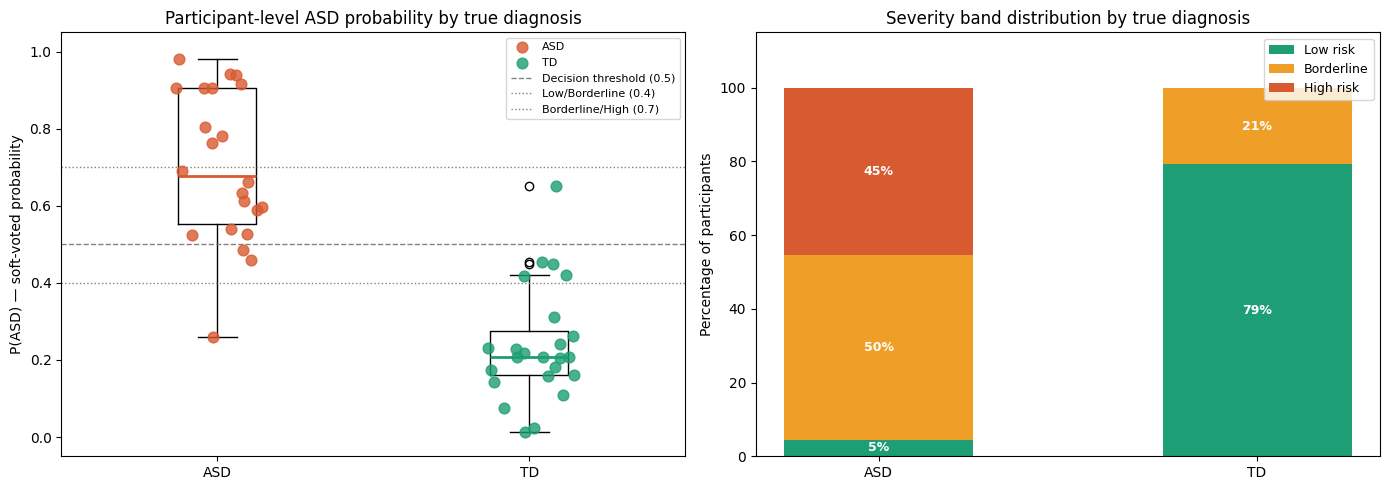

✅ Severity plot saved


In [ ]:
print('─'*65)
print('  Severity Score Distribution')
print('─'*65)
print(f'  Bands: Low risk <{SEV_LOW} | Borderline {SEV_LOW}–{SEV_HIGH} | High risk ≥{SEV_HIGH}')
print()

for grp, label in [(1,'ASD'), (0,'TD')]:
    sub = part_tab[part_tab['y_true'] == grp]
    counts = sub['severity_band'].value_counts()
    print(f'  {label} participants (n={len(sub)}):')
    for band in ['Low risk','Borderline','High risk']:
        n_b = counts.get(band, 0)
        pct = 100*n_b/len(sub) if len(sub)>0 else 0
        print(f'    {band:<12}: {n_b:>2}  ({pct:>5.1f}%)')
    print(f'    Mean P(ASD)  : {sub["y_prob_mean"].mean():.3f}  ±{sub["y_prob_mean"].std():.3f}')
    print()

# ── Severity plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Strip plot: P(ASD) by true group
ax = axes[0]
colors = {'ASD':'#D85A30','TD':'#1D9E75'}
for grp in ['ASD','TD']:
    sub = part_tab[part_tab['y_true'].map({1:'ASD',0:'TD'}) == grp]
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(sub))
    x_pos  = (0 if grp=='ASD' else 1)
    ax.scatter(x_pos + jitter, sub['y_prob_mean'],
               color=colors[grp], alpha=0.8, s=60, zorder=3, label=grp)
    ax.boxplot(sub['y_prob_mean'].values, positions=[x_pos],
               widths=0.25, patch_artist=False,
               medianprops={'color':colors[grp],'linewidth':2})
for thresh, style, lbl in [(0.5,'--','Decision threshold (0.5)'),
                            (SEV_LOW,':',f'Low/Borderline ({SEV_LOW})'),
                            (SEV_HIGH,':',f'Borderline/High ({SEV_HIGH})')]:
    ax.axhline(thresh, color='gray', linestyle=style, linewidth=1, label=lbl)
ax.set_xticks([0,1]); ax.set_xticklabels(['ASD','TD'])
ax.set_ylabel('P(ASD) — soft-voted probability')
ax.set_title('Participant-level ASD probability by true diagnosis')
ax.legend(fontsize=8); ax.set_ylim(-0.05, 1.05)

# Severity band stacked bar
ax = axes[1]
bands = ['Low risk','Borderline','High risk']
band_colors = ['#1D9E75','#EF9F27','#D85A30']
asd_sub = part_tab[part_tab['y_true']==1]
td_sub  = part_tab[part_tab['y_true']==0]
x = np.array([0,1])
bottoms = np.zeros(2)
for band, bc in zip(bands, band_colors):
    vals = [
        100*(asd_sub['severity_band']==band).sum()/max(len(asd_sub),1),
        100*(td_sub['severity_band']==band).sum()/max(len(td_sub),1),
    ]
    ax.bar(x, vals, bottom=bottoms, color=bc, label=band, width=0.5)
    for xi, vi, bo in zip(x, vals, bottoms):
        if vi > 3:
            ax.text(xi, bo+vi/2, f'{vi:.0f}%',
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms += np.array(vals)
ax.set_xticks([0,1]); ax.set_xticklabels(['ASD','TD'])
ax.set_ylabel('Percentage of participants')
ax.set_title('Severity band distribution by true diagnosis')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0,115)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'severity_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Severity plot saved')


### Step 4 — Global Feature Importance
**TabICLv2:** Permutation importance on final model trained on all training participants.  
**XGBoost:** SHAP values (exact Shapley decomposition via `shap` library).  
Both use the globally FDR-selected features and are applied to training data — no holdout data touched.


Training final models on full training set for global importance...
   TabICLv2 final model trained
   XGBoost final model trained

Computing TabICLv2 permutation importance...


  Permutation:   0%|          | 0/12 [00:00<?, ?it/s]

Computing XGBoost SHAP values...


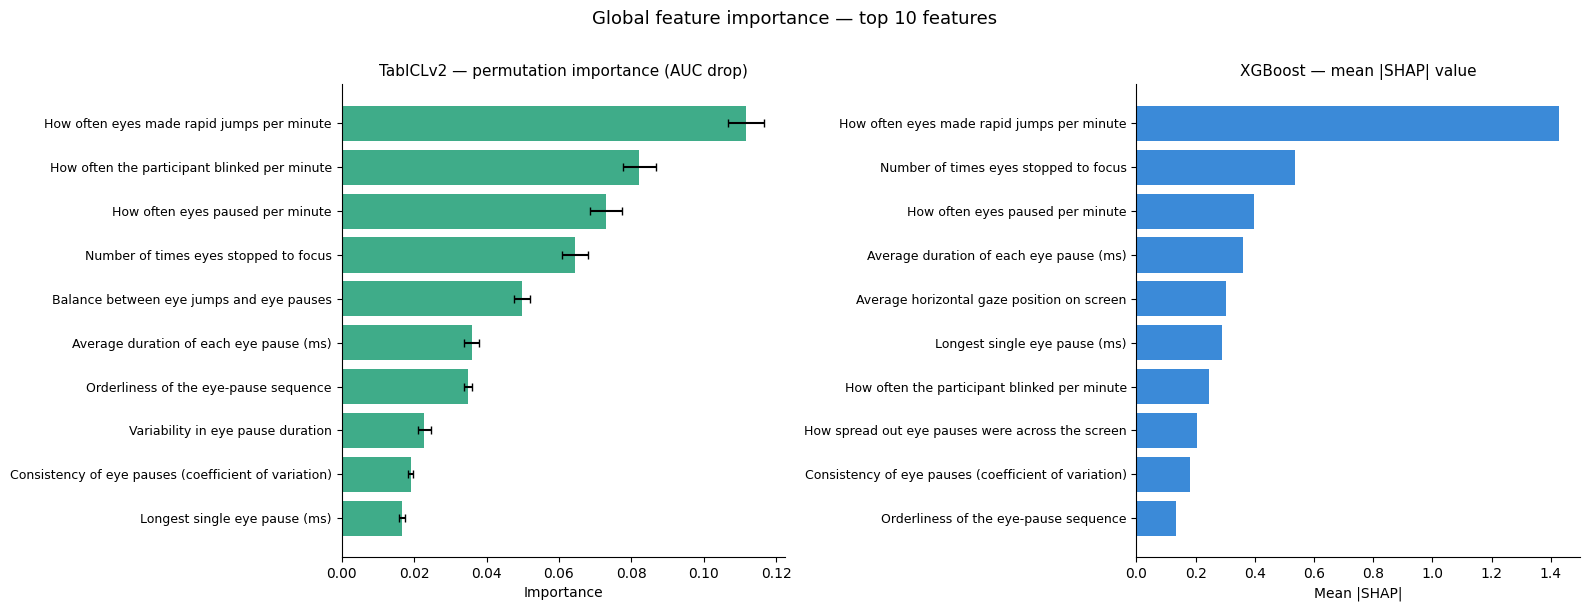

✅ Global importance plots saved


In [ ]:
print('Training final models on full training set for global importance...')

# FDR on full training set (for final model features)
pm_final = df_train.groupby('participant_id')[feat_cols].mean()
pl_final = df_train.groupby('participant_id')['label'].first()
sig_final = fdr_select(pm_final, pl_final.loc[pm_final.index].values)

X_final_df = df_train[sig_final].copy()
y_final    = df_train['label'].values.astype(int)
X_final_np = X_final_df.values.astype(float)

# Train final models
final_tab = make_tabicl_finetuned(seed=RANDOM_STATE)
final_tab.fit(X_final_df, y_final)
print('   TabICLv2 final model trained')

final_xgb = make_xgb(seed=RANDOM_STATE)
final_xgb.fit(X_final_np, y_final)
print('   XGBoost final model trained')

# ── TabICLv2 permutation importance ──────────────────────────────────────────
print('\nComputing TabICLv2 permutation importance...')
baseline_tab = roc_auc_score(y_final, final_tab.predict_proba(X_final_df)[:, 1])
N_REP = 5
tab_imp_mean = np.zeros(len(sig_final))
tab_imp_std  = np.zeros(len(sig_final))
for fi, feat in enumerate(tqdm(sig_final, desc='  Permutation', leave=False)):
    scores = []
    for rep in range(N_REP):
        rng_i  = np.random.default_rng(RANDOM_STATE + fi*100 + rep)
        X_perm = X_final_df.copy()
        X_perm[feat] = rng_i.permutation(X_final_df[feat].values)
        scores.append(baseline_tab - roc_auc_score(y_final,
                          final_tab.predict_proba(X_perm)[:, 1]))
    tab_imp_mean[fi] = np.mean(scores)
    tab_imp_std[fi]  = np.std(scores)

tab_imp_df = (pd.DataFrame({
    'feature':       sig_final,
    'plain_label':   [plain(f) for f in sig_final],
    'importance':    tab_imp_mean.round(4),
    'std':           tab_imp_std.round(4),
}).sort_values('importance', ascending=False))

# ── XGBoost SHAP values ───────────────────────────────────────────────────────
print('Computing XGBoost SHAP values...')
explainer  = shap.TreeExplainer(final_xgb)
shap_vals  = explainer.shap_values(X_final_np)
# shap ≥0.41 returns ndarray shape (n, p, 2); older returns list [class0, class1]
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]
elif shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]
shap_mean  = np.abs(shap_vals).mean(axis=0)

xgb_imp_df = (pd.DataFrame({
    'feature':     sig_final,
    'plain_label': [plain(f) for f in sig_final],
    'shap_mean':   shap_mean.round(4),
}).sort_values('shap_mean', ascending=False))

# ── Save ──────────────────────────────────────────────────────────────────────
tab_imp_df.to_csv(os.path.join(OUTPUT_DIR,'importance_tabicl.csv'), index=False)
xgb_imp_df.to_csv(os.path.join(OUTPUT_DIR,'importance_xgb_shap.csv'), index=False)

# ── Plot side-by-side ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df_imp, val_col, err_col, title, color in [
    (axes[0], tab_imp_df, 'importance', 'std',
     'TabICLv2 — permutation importance (AUC drop)', '#1D9E75'),
    (axes[1], xgb_imp_df, 'shap_mean',  None,
     'XGBoost — mean |SHAP| value', '#1976D2'),
]:
    top = df_imp.head(10)
    labels = [plain(f) for f in top['feature']]
    vals   = top[val_col].values
    errs   = top[err_col].values if err_col else None
    y_pos  = np.arange(len(top))
    ax.barh(y_pos, vals[::-1], xerr=errs[::-1] if errs is not None else None,
            color=color, alpha=0.85, capsize=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels[::-1], fontsize=9)
    ax.set_xlabel('Importance' if val_col=='importance' else 'Mean |SHAP|')
    ax.set_title(title, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Global feature importance — top 10 features', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'importance_global.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Global importance plots saved')


### Step 5 — Per-Participant Local Explanations (ASD-Classified)
For each participant predicted as ASD, we show which features drove the classification and provide plain-language interpretation.  
Uses the **fold's trained model** (same model that produced the prediction) — no holdout data involved.


In [ ]:
def local_explanation_tabicl(fold_info, n_rep=3):
    """
    Permutation-based local importance for one participant.
    Swaps each feature one at a time; measures drop in P(ASD).
    Uses the fold's trained TabICLv2 model — identical to what made the prediction.
    """
    clf   = fold_info['tabicl']
    X_te  = fold_info['X_te_df']
    sig   = fold_info['sig_features']
    base  = fold_info['p_tab']

    imps = {}
    for feat in sig:
        drops = []
        for rep in range(n_rep):
            rng_i  = np.random.default_rng(RANDOM_STATE + rep)
            X_perm = X_te.copy()
            X_perm[feat] = rng_i.permutation(X_te[feat].values)
            p_perm = float(np.mean(clf.predict_proba(X_perm)[:, 1]))
            drops.append(base - p_perm)
        imps[feat] = float(np.mean(drops))
    return dict(sorted(imps.items(), key=lambda x: x[1], reverse=True))

def local_explanation_xgb(fold_info, explainer_xgb=None):
    """SHAP local explanation for XGBoost (per-fold trained model)."""
    clf  = fold_info['xgb']
    X_te = fold_info['X_te_np']
    exp  = shap.TreeExplainer(clf)
    sv   = exp.shap_values(X_te)
    # shap ≥0.41 returns ndarray shape (n, p, 2) for binary; older returns list
    if isinstance(sv, list):
        sv = sv[1]
    elif sv.ndim == 3:
        sv = sv[:, :, 1]
    mean_sv = sv.mean(axis=0)
    return dict(zip(fold_info['sig_features'], mean_sv.tolist()))

# ── Generate explanations for ALL participants ─────────────────────────────────
print('Generating per-participant local explanations...')
explanation_rows = []

for pid, fold_info in tqdm(fold_models.items(), desc='  Explanations'):
    p_tab   = fold_info['p_tab']
    p_xgb   = fold_info['p_xgb']
    true_lbl = fold_info['true_label']

    tab_imps = local_explanation_tabicl(fold_info)
    xgb_imps = local_explanation_xgb(fold_info)

    # Top 3 features by importance
    top3_tab = list(tab_imps.items())[:3]
    top3_xgb = sorted(xgb_imps.items(), key=lambda x: abs(x[1]), reverse=True)[:3]

    explanation_rows.append({
        'participant_id':    pid,
        'true_label':        'ASD' if true_lbl==1 else 'TD',
        'pred_tabicl':       'ASD' if p_tab>=0.5 else 'TD',
        'pred_xgb':          'ASD' if p_xgb>=0.5 else 'TD',
        'p_asd_tabicl':      round(p_tab,3),
        'p_asd_xgb':         round(p_xgb,3),
        'severity_band':     severity_label(p_tab),
        'severity_score':    round(p_tab*100,1),
        'top1_feat':         top3_tab[0][0] if top3_tab else '',
        'top1_plain':        plain(top3_tab[0][0]) if top3_tab else '',
        'top1_importance':   round(top3_tab[0][1],4) if top3_tab else 0,
        'top2_feat':         top3_tab[1][0] if len(top3_tab)>1 else '',
        'top2_plain':        plain(top3_tab[1][0]) if len(top3_tab)>1 else '',
        'top2_importance':   round(top3_tab[1][1],4) if len(top3_tab)>1 else 0,
        'top3_feat':         top3_tab[2][0] if len(top3_tab)>2 else '',
        'top3_plain':        plain(top3_tab[2][0]) if len(top3_tab)>2 else '',
        'top3_importance':   round(top3_tab[2][1],4) if len(top3_tab)>2 else 0,
        'xgb_top1_feat':     top3_xgb[0][0] if top3_xgb else '',
        'xgb_top1_plain':    plain(top3_xgb[0][0]) if top3_xgb else '',
        'xgb_top1_shap':     round(top3_xgb[0][1],4) if top3_xgb else 0,
    })

exp_df = pd.DataFrame(explanation_rows)
exp_df.to_csv(os.path.join(OUTPUT_DIR,'participant_explanations.csv'), index=False)

# ── Print ASD-classified participants ─────────────────────────────────────────
print('\n' + '─'*75)
print('  Per-participant explanation — predicted ASD (TabICLv2)')
print('─'*75)
asd_pred = exp_df[exp_df['pred_tabicl']=='ASD'].sort_values('p_asd_tabicl', ascending=False)
for _, row in asd_pred.iterrows():
    correct = '✅' if row['true_label']==row['pred_tabicl'] else '❌'
    print(f"\n  Participant {row['participant_id']} {correct}  "          f"[true={row['true_label']}]  P(ASD)={row['p_asd_tabicl']:.3f}  "          f"Severity: {row['severity_band']} ({row['severity_score']})")
    print(f"    Why classified as ASD (TabICLv2):")
    for rank, feat_key, plain_key, imp_key in [
        ('1st', 'top1_feat','top1_plain','top1_importance'),
        ('2nd', 'top2_feat','top2_plain','top2_importance'),
        ('3rd', 'top3_feat','top3_plain','top3_importance'),
    ]:
        if row[feat_key]:
            direction = '↑ higher than TD' if row[imp_key] > 0 else '↓ lower than TD'
            print(f"      {rank}: {row[plain_key]}  [{row[feat_key]}]  "                  f"(impact={row[imp_key]:+.4f}, {direction})")

print(f'\n✅ Explanations saved → participant_explanations.csv')

Generating per-participant local explanations...


  Explanations:   0%|          | 0/46 [00:00<?, ?it/s]


───────────────────────────────────────────────────────────────────────────
  Per-participant explanation — predicted ASD (TabICLv2)
───────────────────────────────────────────────────────────────────────────

  Participant 14 ✅  [true=ASD]  P(ASD)=0.980  Severity: High risk (98.0)
    Why classified as ASD (TabICLv2):
      1st: Number of times eyes stopped to focus  [fix_count]  (impact=+0.0717, ↑ higher than TD)
      2nd: Orderliness of the eye-pause sequence  [fix_seq_norm]  (impact=+0.0539, ↑ higher than TD)
      3rd: Balance between eye jumps and eye pauses  [sac_fix_ratio]  (impact=+0.0509, ↑ higher than TD)

  Participant 7 ✅  [true=ASD]  P(ASD)=0.942  Severity: High risk (94.2)
    Why classified as ASD (TabICLv2):
      1st: Variability in eye pause duration  [fix_dur_std_ms]  (impact=+0.0136, ↑ higher than TD)
      2nd: Consistency of eye pauses (coefficient of variation)  [fix_dur_cv]  (impact=+0.0126, ↑ higher than TD)
      3rd: Longest single eye pause (ms)  [fix_dur

### Step 6 — Permutation Test (Label Shuffle)
Tests whether the observed AUC is better than chance. N_PERM=1000 for a camera-ready paper.


  Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]


  Observed AUC = 0.970  |  Null mean = 0.513  |  p = 0.0050
  ✅ Significant at α=0.05


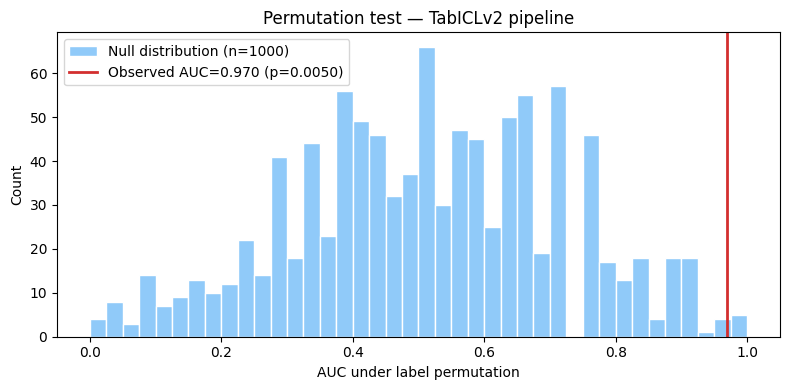

✅ Permutation test saved


In [ ]:
observed_auc = ci_tab['auc'][0]

if N_PERM == 0:
    print('⏭  Permutation test skipped (N_PERM=0)')
    null_aucs, emp_p = np.array([]), float('nan')
else:
    rng      = np.random.default_rng(RANDOM_STATE)
    parts    = df_train['participant_id'].unique().tolist()
    y_arr    = df_train.groupby('participant_id')['label'].first().loc[parts].values.astype(int)
    null_aucs = []

    for i in tqdm(range(N_PERM), desc='  Permutations'):
        y_shuf = rng.permutation(y_arr)
        n      = len(parts)
        tr_idx = rng.choice(n, int(n*0.8), replace=False)
        te_idx = np.setdiff1d(np.arange(n), tr_idx)
        if len(np.unique(y_shuf[te_idx])) < 2: continue
        tr_pids = [parts[j] for j in tr_idx]
        te_pids = [parts[j] for j in te_idx]
        df_tr_p = df_train[df_train['participant_id'].isin(tr_pids)].copy()
        df_te_p = df_train[df_train['participant_id'].isin(te_pids)].copy()
        # Shuffle labels at participant level
        lmap = dict(zip(parts, y_shuf))
        df_tr_p['label'] = df_tr_p['participant_id'].map(lmap)
        pm_p = df_tr_p.groupby('participant_id')[feat_cols].mean()
        pl_p = df_tr_p.groupby('participant_id')['label'].first()
        sig_p = fdr_select(pm_p, pl_p.loc[pm_p.index].values)
        clf_p = make_tabicl(seed=RANDOM_STATE + i)
        clf_p.fit(df_tr_p[sig_p].copy(), df_tr_p['label'].values.astype(int))
        probs_p = clf_p.predict_proba(df_te_p[sig_p].copy())[:, 1]
        pdf = (pd.DataFrame({'pid': df_te_p['participant_id'].values,
                              'p': probs_p,
                              'yt': df_te_p['participant_id'].map(lmap).values})
                 .groupby('pid').agg(p=('p','mean'), yt=('yt','first')))
        if len(np.unique(pdf['yt'])) < 2: continue
        null_aucs.append(roc_auc_score(pdf['yt'], pdf['p']))

    null_aucs = np.array(null_aucs)
    emp_p     = float((null_aucs >= observed_auc).sum() / len(null_aucs))
    print(f'\n  Observed AUC = {observed_auc:.3f}  |  Null mean = {null_aucs.mean():.3f}  |  p = {emp_p:.4f}')
    print(f'  {"✅ Significant" if emp_p < ALPHA else "❌ NOT significant"} at α={ALPHA}')

    fig, ax = plt.subplots(figsize=(8,4))
    ax.hist(null_aucs, bins=40, color='#90CAF9', edgecolor='white',
            label=f'Null distribution (n={len(null_aucs)})')
    ax.axvline(observed_auc, color='#D32F2F', lw=2,
               label=f'Observed AUC={observed_auc:.3f} (p={emp_p:.4f})')
    ax.set_xlabel('AUC under label permutation'); ax.set_ylabel('Count')
    ax.set_title('Permutation test — TabICLv2 pipeline'); ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'permutation_test.png'), dpi=300, bbox_inches='tight')
    plt.show()
    pd.DataFrame({'observed_auc':[observed_auc], 'n_perms':[len(null_aucs)],
                  'null_mean':[round(null_aucs.mean(),4)],
                  'null_std':[round(null_aucs.std(),4)],
                  'empirical_p':[round(emp_p,4)]}).to_csv(
        os.path.join(OUTPUT_DIR,'permutation_test.csv'), index=False)
    print('✅ Permutation test saved')


### Step 7 — ROC Curves & Calibration


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── ROC curves — all three models ────────────────────────────────────────────
ax = axes[0]
roc_models = [
    (part_tab['y_prob_mean'], 'TabICLv2', '#D85A30', ci_tab),
    (part_pfn['y_prob_mean'], 'TabPFN',   '#7B1FA2', ci_pfn),
    (part_xgb['y_prob_mean'], 'XGBoost',  '#1976D2', ci_xgb),
]
y_true_ref = part_tab['y_true']
for probs, label, color, ci in roc_models:
    fpr, tpr, _ = roc_curve(y_true_ref, probs)
    auc_pt, auc_lo, auc_hi = ci['auc']
    ax.plot(fpr, tpr, lw=2, color=color,
            label=f'{label}  AUC={auc_pt:.3f} [{auc_lo:.3f}, {auc_hi:.3f}]')
ax.plot([0,1],[0,1],'k--',lw=1,label='Chance')
ax.fill_between([0,1],[0,1],alpha=0.05,color='gray')
ax.set_xlabel('1 – Specificity (FPR)'); ax.set_ylabel('Sensitivity (TPR)')
ax.set_title('ROC curves — LOOCV participant-level')
ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# ── Probability distributions (TabICLv2, primary) ────────────────────────────
ax = axes[1]
for grp, grp_label, color in [(1,'ASD','#D85A30'), (0,'TD','#1D9E75')]:
    vals = part_tab[part_tab['y_true']==grp]['y_prob_mean'].values
    ax.hist(vals, bins=12, alpha=0.6, color=color, label=grp_label, edgecolor='white')
ax.axvline(0.5, color='gray', lw=1.5, linestyle='--', label='Threshold 0.5')
ax.set_xlabel('P(ASD) — TabICLv2 soft-voted probability')
ax.set_ylabel('Number of participants')
ax.set_title('P(ASD) distribution by true diagnosis (TabICLv2)')
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'roc_and_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ ROC and distribution plots saved')


### Step 8 — Holdout Evaluation (ONE-TIME, gated)
> This cell runs **once only**. A flag file prevents repeated evaluation to eliminate p-hacking. Do not delete the flag file unless you have a genuinely new train/test split.


In [ ]:
if os.path.exists(HOLDOUT_FLAG):
    print('*** HOLDOUT ALREADY EVALUATED — skipping to prevent p-hacking ***')
    print(f'    Flag: {HOLDOUT_FLAG}')
else:
    X_hold_df = df_holdout[sig_final].copy()
    X_hold_np = X_hold_df.values.astype(float)
    y_hold    = df_holdout['label'].values.astype(int)

    probs_hold_tab = final_tab.predict_proba(X_hold_df)[:, 1]
    probs_hold_xgb = final_xgb.predict_proba(X_hold_np)[:, 1]

    # TabPFN holdout — use final model trained on full training set
    if HAS_TABPFN:
        final_pfn = make_tabpfn(seed=RANDOM_STATE)
        # Respect TabPFN 1 000-sample cap
        if len(X_final_np) > 1000:
            rng_h = np.random.default_rng(RANDOM_STATE)
            idx0 = np.where(y_final==0)[0]; idx1 = np.where(y_final==1)[0]
            n0 = min(len(idx0), 500); n1 = min(len(idx1), 1000-n0)
            sel = np.concatenate([rng_h.choice(idx0,n0,replace=False),
                                  rng_h.choice(idx1,n1,replace=False)])
            final_pfn.fit(X_final_np[sel], y_final[sel])
        else:
            final_pfn.fit(X_final_np, y_final)
        probs_hold_pfn = final_pfn.predict_proba(X_hold_np)[:, 1]
    else:
        probs_hold_pfn = np.full(len(X_hold_np), np.nan)
        print('⚠️  TabPFN unavailable — holdout skipped for TabPFN')

    part_hold_tab = aggregate_to_participant(
        df_holdout['participant_id'].values, y_hold, probs_hold_tab, threshold=0.5)
    part_hold_pfn = aggregate_to_participant(
        df_holdout['participant_id'].values, y_hold, probs_hold_pfn, threshold=0.5)
    part_hold_xgb = aggregate_to_participant(
        df_holdout['participant_id'].values, y_hold, probs_hold_xgb, threshold=0.5)
    part_hold_tab = add_severity(part_hold_tab)

    hold_ci_tab = bootstrap_metrics(part_hold_tab['y_true'], part_hold_tab['y_prob_mean'],
                                    threshold=0.5, n_boot=N_BOOT)
    hold_ci_pfn = bootstrap_metrics(part_hold_pfn['y_true'], part_hold_pfn['y_prob_mean'],
                                    threshold=0.5, n_boot=N_BOOT)
    hold_ci_xgb = bootstrap_metrics(part_hold_xgb['y_true'], part_hold_xgb['y_prob_mean'],
                                    threshold=0.5, n_boot=N_BOOT)

    print_metrics(hold_ci_tab, f'TabICLv2 HOLDOUT (n={len(part_hold_tab)}, threshold=0.500)',
                  len(part_hold_tab), 0.5)
    print_metrics(hold_ci_pfn, f'TabPFN   HOLDOUT (n={len(part_hold_pfn)}, threshold=0.500)',
                  len(part_hold_pfn), 0.5)
    print_metrics(hold_ci_xgb, f'XGBoost  HOLDOUT (n={len(part_hold_xgb)}, threshold=0.500)',
                  len(part_hold_xgb), 0.5)

    with open(HOLDOUT_FLAG, 'w') as f: f.write(datetime.datetime.now().isoformat())
    part_hold_tab.to_csv(os.path.join(OUTPUT_DIR,'holdout_tabicl.csv'), index=False)
    part_hold_pfn.to_csv(os.path.join(OUTPUT_DIR,'holdout_tabpfn.csv'), index=False)
    part_hold_xgb.to_csv(os.path.join(OUTPUT_DIR,'holdout_xgb.csv'), index=False)
    print('\n✅ Holdout results saved (flag written — will not re-run)')


In [ ]:
print('\n' + '='*72)
print('  FINAL SUMMARY')
print('='*72)
print(f'\n  Dataset      : {n_all} participants  (ASD={asd_n}, TD={td_n})')
print(f'  Train        : {len(train_ids)} participants  |  Holdout: {len(holdout_ids)}')
print(f'  Features     : {len(sig_final)} survived FDR (from {len(feat_cols)})')
print(f'  LOOCV folds  : {df_train["participant_id"].nunique()}  (one per participant)')
print(f'  Threshold    : 0.500 (primary)  |  Youden-J {best_thresh_tab:.3f} (secondary)')

for model_label, ci, d in [
    ('TabICLv2', ci_tab, d_tab),
    ('TabPFN',   ci_pfn, d_pfn),
    ('XGBoost',  ci_xgb, d_xgb),
]:
    print(f'\n  ── {model_label} LOOCV ──')
    for k,(pt,lo,hi) in ci.items():
        n = {'auc':'AUC','sens':'Sensitivity','spec':'Specificity',
             'f1':'F1','acc':'Accuracy','brier':'Brier'}.get(k,k)
        print(f'    {n:<14} {pt:.3f}  [{lo:.3f}, {hi:.3f}]')
    print(f"    Cohen's d    {d:.3f}")

print(f'\n  ── Pairwise McNemar tests ──')
print(f'    TabICLv2 vs TabPFN  p = {mc_pvalue_tab_pfn:.4f}')
print(f'    TabICLv2 vs XGBoost p = {mc_pvalue_tab_xgb:.4f}')
print(f'    Permutation test    p = {emp_p:.4f}  (N={len(null_aucs)})')

print(f'\n  ── Severity (TabICLv2, training set) ──')
for band in ['Low risk','Borderline','High risk']:
    n_b = (part_tab['severity_band']==band).sum()
    print(f'    {band:<12}: {n_b} participants')

print(f'\n  ── Outputs in {OUTPUT_DIR}/ ──')
outputs = [
    'split_indices.json', 'feature_statistics.csv',
    'loocv_fold_results.csv',
    'loocv_tabicl_participants.csv', 'loocv_tabpfn_participants.csv', 'loocv_xgb_participants.csv',
    'metrics_tabicl.csv', 'metrics_tabpfn.csv', 'metrics_xgb.csv',
    'table_loocv_latex.tex',
    'mcnemar_tests.csv', 'permutation_test.csv', 'permutation_test.png',
    'importance_tabicl.csv', 'importance_xgb_shap.csv', 'importance_global.png',
    'participant_explanations.csv', 'severity_distribution.png',
    'roc_and_distributions.png',
    'holdout_tabicl.csv', 'holdout_tabpfn.csv', 'holdout_xgb.csv',
]
for fname in outputs:
    p = os.path.join(OUTPUT_DIR, fname)
    tag = '✅' if os.path.exists(p) else '  (pending)'
    print(f'  {tag}  {fname}')
print('='*72)
